In [ ]:
# Kết nối với Google Drive của bạn nhằm lưu trữ dataset và các tệp trọng số khi train xong
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 115.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
httpx2 2.4.0 requires idna>=3.18, but you have idna 3.7 which is incompatible.


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="3OEqKlaUTLNgrFZGJiv6")
project = rf.workspace("traffic-lights-vfrfv").project("yolov8-sgdlx-2i8mm")
version = project.version(1)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to yolov8-1 in yolov8:: 100%|██████████| 10310/10310 [00:08<00:00, 1256.12it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(
    data="/content/yolov8-1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    device=0
)

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov8-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, pers

In [ ]:
from ultralytics import YOLO
import numpy as np

# Load model
model = YOLO("/content/light_traffic.pt")

# Đánh giá model
metrics = model.val(
    data="/content/yolov8-1/data.yaml",
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.6,
    verbose=False
)

print("=" * 60)
print("TRAFFIC LIGHT EVALUATION")
print("=" * 60)

traffic_maps = []

for i, name in model.names.items():
    if "trafficLight" in name:
        map95 = metrics.box.maps[i]
        traffic_maps.append(map95)
        print(f"{name:<28} mAP50-95: {map95:.4f}")

print("-" * 60)
print(f"Average TrafficLight mAP50-95 : {np.mean(traffic_maps):.4f}")

print("\nOVERALL METRICS")
print("-" * 60)
print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")
print(f"mAP@0.50  : {metrics.box.map50:.4f}")
print(f"mAP@0.50:0.95 : {metrics.box.map:.4f}")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 11,130,228 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 534.2±644.7 MB/s, size: 141.1 KB)
val: Scanning /content/yolov8-1/test/labels... 233 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 233/233 1.3Kit/s 0.2s
val: New cache created: /content/yolov8-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 8.4s/it 2:05
                   all        233        671      0.917      0.911      0.897      0.617
Speed: 4.6ms preprocess, 512.3ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val
TRAFFIC LIGHT EVALUATION
trafficLight                 mAP50-95: 0.5864
trafficLight-Green           mAP50-95: 0.6448
trafficLight-GreenLeft       mAP50-95: 0.5854
trafficLight-Red             mAP50-95: 0.5042
trafficLight-R

In [ ]:
from google.colab import files

files.download(
    "/content/runs/detect/train/weights/best.pt"
)

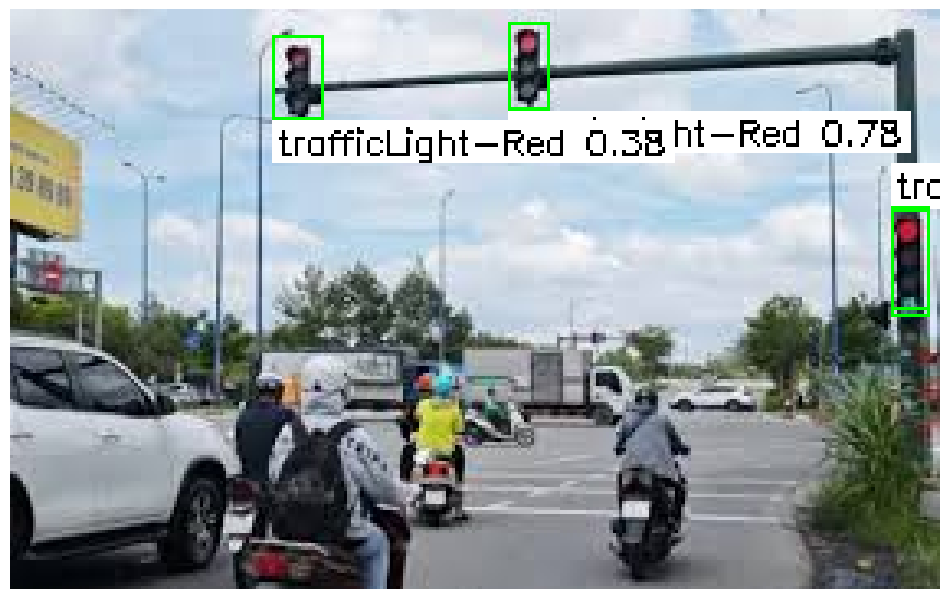

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("/content/traffic_light.pt")

image_path = "/content/l.jpg"
img = cv2.imread(image_path)

results = model.predict(
    source=image_path,
    conf=0.25,
    verbose=False
)

for r in results:
    for box in r.boxes:

        cls = int(box.cls[0])
        name = model.names[cls]

        # Kiểm tra xem có phải là đèn tín hiệu không (tùy thuộc vào bộ dataset của bạn)
        if "trafficLight" not in name:
            continue

        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Vẽ khung bao quanh đèn (Màu xanh lá - BGR: 0, 255, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)

        # CẬP NHẬT: Hiển thị cả TÊN LỚP (MÀU) + CONFIDENCE
        label = f"{name} {conf:.2f}"

        # Cấu hình Font chữ nhỏ để tránh đè nhau tại ngã tư
        font_scale = 0.35
        thickness = 1

        (tw, th), _ = cv2.getTextSize(
            label,
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            thickness
        )

        # Nếu sát mép trên ảnh thì đưa chữ xuống dưới bounding box
        text_y = y1 - 3
        if text_y < th:
            text_y = y2 + th + 3

        # Vẽ nền nhãn (Màu TRẮNG - BGR: 255, 255, 255)
        # Nếu muốn đổi lại nền xanh lá giống hình cũ của bạn, hãy thay (255, 255, 255) bằng (0, 255, 0)
        cv2.rectangle(
            img,
            (x1, text_y - th - 2),
            (x1 + tw + 2, text_y + 2),
            (255, 255, 255),
            -1
        )

        # Viết chữ đè lên nền (Màu ĐEN - BGR: 0, 0, 0)
        cv2.putText(
            img,
            label,
            (x1 + 1, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (0, 0, 0),
            thickness
        )

# Hiển thị ảnh kết quả bằng Matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


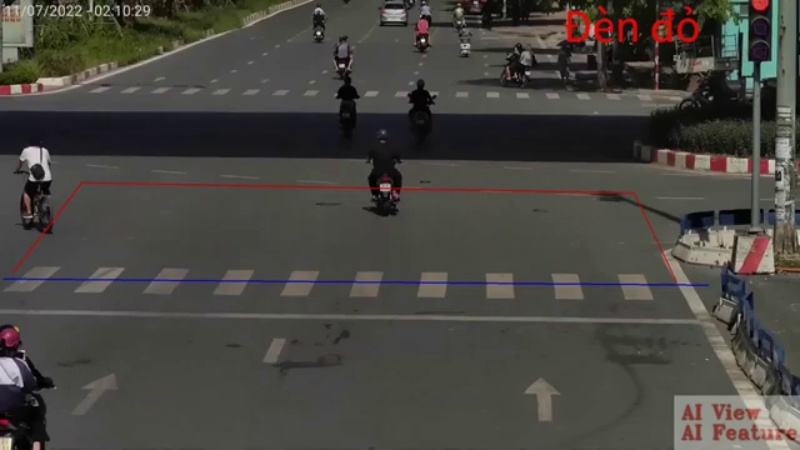


 CHỈ CẦN THAY THẾ CẢ ĐOẠN DƯỚI ĐÂY VÀO MỤC 1 TRONG CODE CHẠY VIDEO 
src_points = np.float32([
    [6, 221],   # 1. Duoi - Trai
    [541, 226],   # 2. Duoi - Phai
    [509, 152],   # 3. Tren - Phai
    [68, 145]    # 4. Tren - Trai
])



In [ ]:
import cv2
import json
import base64
from google.colab import output
from IPython.display import HTML, display

# Đường dẫn video của bạn
video_path = "/content/traffic_video.mp4"
cap = cv2.VideoCapture(video_path)
ret, first_frame = cap.read()
cap.release()

if ret:
    # Resize tạm thời để hiển thị vừa vặn trên màn hình Colab
    h, w, _ = first_frame.shape
    display_w = 800
    display_h = int(h * (display_w / w))
    img_resized = cv2.resize(first_frame, (display_w, display_h))
    _, buffer = cv2.imencode('.jpg', img_resized)
    b64_str = base64.b64encode(buffer).decode('utf-8')

    # Giao diện HTML + JavaScript hỗ trợ vẽ HÌNH THANG 3D (4 điểm)
    canvas_html = f"""
    <div style="background: #222; padding: 15px; border-radius: 8px; color: white; font-family: sans-serif; width: {display_w}px;">
        <h3 style="margin-top: 0; color: #00aaff;"> 🛠️ CÔNG CỤ XÁC ĐỊNH VÙNG HÌNH THANG 3D</h3>
        <p id="instruction" style="color: #ffca28; font-weight: bold; font-size: 15px;">👉 Bước 1: Click điểm 1 (DƯỚI - TRÁI) sát rìa đường gần camera</p>

        <div style="position: relative; display: inline-block;">
            <img id="roi_img" src="data:image/jpeg;base64,{b64_str}" width="{display_w}" height="{display_h}" style="cursor: crosshair; user-select: none; -webkit-user-drag: none;"/>
            <canvas id="roi_canvas" width="{display_w}" height="{display_h}" style="position: absolute; top: 0; left: 0; pointer-events: none;"></canvas>
        </div>
        <br/>
        <button id="reset_btn" style="margin-top:10px; padding:8px 15px; background:#dc3545; color:#fff; border:none; cursor:pointer; border-radius: 4px; margin-right: 10px; font-weight: bold;">Xóa vẽ lại</button>
        <button id="confirm_btn" style="margin-top:10px; padding:8px 15px; background:#28a745; color:#fff; border:none; cursor:pointer; border-radius: 4px; font-weight: bold;">Xác nhận vùng hình thang 3D</button>
    </div>

    <script>
        var points = []; // Lưu tối đa 4 điểm mốc

        var img = document.getElementById('roi_img');
        var canvas = document.getElementById('roi_canvas');
        var ctx = canvas.getContext('2d');
        var instruction = document.getElementById('instruction');

        var steps = [
            "👉 Bước 1: Click điểm 1 (DƯỚI - TRÁI) sát rìa đường gần camera",
            "👉 Bước 2: Click điểm 2 (DƯỚI - PHẢI) song song mép đường gần camera",
            "👉 Bước 3: Click điểm 3 (TRÊN - PHẢI) tiến lên gần sát ngã tư",
            "👉 Bước 4: Click điểm 4 (TRÊN - TRÁI) sát ngã tư để khép kín hình thang",
            "✅ Đã chọn đủ 4 điểm! Bấm 'Xác nhận vùng hình thang 3D' để lấy tọa độ."
        ];

        function redraw() {{
            ctx.clearRect(0, 0, canvas.width, canvas.height);

            // Cấu hình nét vẽ đa giác vùng (Xanh dương rực rỡ)
            ctx.fillStyle = "#00e5ff";
            ctx.strokeStyle = "#00e5ff";
            ctx.lineWidth = 3;

            // Vẽ các chấm điểm mốc tròn
            points.forEach((p, index) => {{
                ctx.beginPath();
                ctx.arc(p[0], p[1], 6, 0, 2 * Math.PI);
                ctx.fill();
                ctx.font = "bold 14px sans-serif";
                ctx.fillText(" " + (index + 1), p[0] + 8, p[1] + 5);
            }});

            // Vẽ các đường nối liên tiếp
            if (points.length > 0) {{
                ctx.beginPath();
                ctx.moveTo(points[0][0], points[0][1]);
                for (var i = 1; i < points.length; i++) {{
                    ctx.lineTo(points[i][0], points[i][1]);
                }}
                // Nếu đủ 4 điểm, tự động đóng kín hình thang
                if (points.length === 4) {{
                    ctx.closePath();
                    // Đổ màu mờ bên trong lòng hình thang để dễ kiểm tra độ phủ
                    ctx.fillStyle = "rgba(0, 229, 255, 0.2)";
                    ctx.fill();
                }}
                ctx.stroke();
            }}
        }}

        img.addEventListener('click', function(e) {{
            if (points.length >= 4) return;

            var rect = img.getBoundingClientRect();
            var x = e.clientX - rect.left;
            var y = e.clientY - rect.top;

            points.push([x, y]);

            if (points.length < 4) {{
                instruction.innerHTML = steps[points.length];
                instruction.style.color = "#ffca28";
            }} else {{
                instruction.innerHTML = steps[4];
                instruction.style.color = "#28a745";
            }}
            redraw();
        }});

        document.getElementById('reset_btn').addEventListener('click', function() {{
            points = [];
            instruction.innerHTML = steps[0];
            instruction.style.color = "#ffca28";
            redraw();
        }});

        document.getElementById('confirm_btn').addEventListener('click', function() {{
            if (points.length < 4) {{
                alert("Vui lòng click đủ 4 điểm theo đúng vòng tuần tự để tạo thành hình thang!");
                return;
            }}
            // Gửi dữ liệu mảng 4 điểm về Python xử lý scale gốc
            google.colab.kernel.invokeFunction('notebook.save_3d_points', [points, {w}, {display_w}, {h}, {display_h}], {{}});
        }});
    </script>
    """

    def save_3d_points(pts, orig_w, disp_w, orig_h, disp_h):
        scale_x = orig_w / disp_w
        scale_y = orig_h / disp_h

        # Quy đổi ngược từ pixel hiển thị về pixel video gốc 100%
        final_points = [[int(p[0] * scale_x), int(p[1] * scale_y)] for p in pts]

        print("\n" + "="*70)
        print(" CHỈ CẦN THAY THẾ CẢ ĐOẠN DƯỚI ĐÂY VÀO MỤC 1 TRONG CODE CHẠY VIDEO ")
        print("="*70)
        print("src_points = np.float32([")
        print(f"    {final_points[0]},   # 1. Duoi - Trai")
        print(f"    {final_points[1]},   # 2. Duoi - Phai")
        print(f"    {final_points[2]},   # 3. Tren - Phai")
        print(f"    {final_points[3]}    # 4. Tren - Trai")
        print("])")
        print("="*70 + "\n")

    output.register_callback('notebook.save_3d_points', save_3d_points)
    display(HTML(canvas_html))
else:
    print("Không thể trích xuất khung hình từ video, hãy kiểm tra lại biến video_path.")

In [ ]:
import cv2
import numpy as np
import base64
from datetime import datetime
from ultralytics import YOLO
from IPython.display import display, HTML

# ==========================================
# 1. Cấu hình Mô hình và Ma trận Không gian 3D
# ==========================================
model = YOLO("/content/traffic_light.pt")
video_path = "/content/1.mp4"
cap = cv2.VideoCapture(video_path)

src_points = np.float32([
    [518, 705],    # 1. Duoi - Trai
    [1444, 804],   # 2. Duoi - Phai
    [1480, 602],   # 3. Tren - Phai
    [835, 600]     # 4. Tren - Trai
])

dst_points = np.float32([
    [0, 600],     # Dưới - Trái
    [400, 600],   # Dưới - Phải
    [400, 0],     # Trên - Phải
    [0, 0]        # Trên - Trái
])

M = cv2.getPerspectiveTransform(src_points, dst_points)
STOP_LINE_3D_Y = 400

def convert_to_3d_point(cx, cy, transform_matrix):
    point = np.array([[[cx, cy]]], dtype=np.float32)
    transformed_point = cv2.perspectiveTransform(point, transform_matrix)
    return transformed_point[0][0]

# ==========================================
# 3. Khởi tạo giao diện HTML
# ==========================================
ui_html = """
<div style="display: flex; flex-direction: column; align-items: center; background: #1e1e1e; padding: 15px; border-radius: 8px; width: 870px;">
    <div id="video_container">
        <img id="video_frame" src="" width="850" style="border-radius: 4px;"/>
    </div>
    <div style="width: 850px; margin-top: 15px;">
        <h4 style="color: #00aaff; margin: 5px 0; font-family: sans-serif;"> HỆ THỐNG GIÁM SÁT KHÔNG GIAN 3D (BIRD'S EYE VIEW):</h4>
        <div id="log_container" style="background: #000; color: #00ff00; font-family: monospace; height: 160px; overflow-y: scroll; padding: 10px; border: 1px solid #333; border-radius: 4px; text-align: left; font-size: 13px; line-height: 1.6;">
            [Đã thiết lập hệ thống ghi nhận vi phạm độc lập - Cảnh báo 1 lần duy nhất]...<br/>
        </div>
    </div>
</div>

<script>
    function appendViolationLog(text) {
        var logDiv = document.getElementById('log_container');
        logDiv.innerHTML += text + "<br/>";
        logDiv.scrollTop = logDiv.scrollHeight;
    }
    function updateVideoFrame(base64_img) {
        document.getElementById('video_frame').src = "data:image/jpeg;base64," + base64_img;
    }
</script>
"""

display_handle = display(HTML(ui_html), display_id=True)

officially_violated_ids = set() # Tập hợp lưu những xe ĐÃ BỊ PHẠT (Giữ khung đỏ mãi mãi)
logged_violated_ids = set()     # Tập hợp lưu những xe ĐÃ IN LOG (Chống trùng lặp tin nhắn)

# --- KHỞI TẠO BỘ NHỚ ĐỆM ĐÈN TÍN HIỆU ---
red_light_counter = 0
RED_LIGHT_BUFFER_FRAMES = 30

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Tính toán vạch dừng ảo bằng ma trận nghịch đảo
    line_3d_pts = np.array([[[0, STOP_LINE_3D_Y]], [[400, STOP_LINE_3D_Y]]], dtype=np.float32)
    M_inv = np.linalg.inv(M)
    line_2d_pts = cv2.perspectiveTransform(line_3d_pts, M_inv)
    left_x, left_y = map(int, line_2d_pts[0][0])
    right_x, right_y = map(int, line_2d_pts[1][0])

    # Vẽ vùng hình thang kiểm soát và vạch dừng
    pts = src_points.astype(np.int32)
    cv2.polylines(frame, [pts], True, (255, 255, 0), 2)
    cv2.line(frame, (left_x, left_y), (right_x, right_y), (0, 152, 255), 4)

    # Tracking YOLO
    results = model.track(source=frame, conf=0.20, persist=True, verbose=False)

    # 🚦 LOGIC LỌC NHẤP NHÁY ĐÈN ĐỎ
    yolo_detected_red = False
    for r in results:
        if r.boxes is None: continue
        for box in r.boxes:
            cls = int(box.cls[0])
            name = model.names[cls]
            if "trafficLight" in name and "red" in name.lower():
                yolo_detected_red = True
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)

    if yolo_detected_red:
        red_light_counter = RED_LIGHT_BUFFER_FRAMES
    else:
        if red_light_counter > 0:
            red_light_counter -= 1

    is_red_light_active = (red_light_counter > 0)

    for r in results:
        if r.boxes is None: continue
        for box in r.boxes:
            cls = int(box.cls[0])
            name = model.names[cls]
            if "trafficLight" in name: continue

            track_id = int(box.id[0]) if box.id is not None else 0
            unique_key = f"{name}_{track_id}"

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cx = int((x1 + x2) / 2)
            cy_tail = y2

            # Chuyển đổi tọa độ sang 3D Bird's Eye View
            x_3d, y_3d = convert_to_3d_point(cx, cy_tail, M)

            # Kiểm tra xe có nằm trong lòng hình thang hay không
            is_inside_zone = (0 <= x_3d <= 400) and (0 <= y_3d <= 600)
            is_past_line_3d = is_inside_zone and (y_3d < STOP_LINE_3D_Y)

            color = (0, 255, 0)
            label = unique_key

            # Nếu xe này ĐÃ TỪNG bị bắt vi phạm trước đó, ghim cứng khung đỏ (Dù đèn có xanh lại hay xe đi đâu)
            if unique_key in officially_violated_ids:
                color = (0, 0, 255)
                label = f"VI PHAM 3D! {unique_key.upper()}"
                cv2.rectangle(frame, (x1, y1 - 20), (x1 + 180, y1), (0, 0, 255), -1)
                cv2.putText(frame, label, (x1 + 5, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

            # Nếu đang đèn đỏ và xe thực sự mới vượt vạch lần đầu
            elif is_red_light_active and is_past_line_3d:
                officially_violated_ids.add(unique_key) # Đưa vào danh sách đen để ghim khung đỏ

                color = (0, 0, 255)
                label = f"VI PHAM 3D! {unique_key.upper()}"
                cv2.rectangle(frame, (x1, y1 - 20), (x1 + 180, y1), (0, 0, 255), -1)
                cv2.putText(frame, label, (x1 + 5, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

                # KIỂM TRA: Chỉ bắn log lên màn hình đúng 1 lần duy nhất cho ID này
                if unique_key not in logged_violated_ids:
                    logged_violated_ids.add(unique_key)
                    current_time = datetime.now().strftime("%H:%M:%S")
                    log_text = f"<span style='color:#ff4d4d;'>[{current_time}] 🔴 HỆ THỐNG 3D: Xe <b>{unique_key.upper()}</b> vượt ranh giới 3D khi đèn đỏ!</span>"
                    display(HTML(f"<script>appendViolationLog(\"{log_text}\");</script>"), display_id="log_agent")

            # Đèn đỏ nhưng xe chưa vượt vạch
            elif is_red_light_active:
                color = (0, 255, 255)
                label = f"DUNG CHO: {unique_key}"
                cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

            # Đèn xanh/vàng bình thường
            else:
                cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

    # Hiển thị trạng thái hệ thống
    status_text = "HE THONG 3D: DANG DEN DO" if is_red_light_active else "HE THONG 3D: DEN XANH / VANG"
    status_color = (0, 0, 255) if is_red_light_active else (0, 255, 0)
    cv2.putText(frame, status_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2)

    # Render kết quả lên màn hình Colab
    _, buffer = cv2.imencode('.jpg', frame)
    b64_str = base64.b64encode(buffer).decode('utf-8')
    display(HTML(f"<script>updateVideoFrame('{b64_str}');</script>"), display_id="video_agent")

cap.release()
print("🎉 Đã tối ưu cấu trúc lưu vết: Thông báo duy nhất 1 lần và khóa mục tiêu bằng khung đỏ liên tục!")

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 248ms
Prepared 1 package in 57ms
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



🎉 Đã tối ưu cấu trúc lưu vết: Thông báo duy nhất 1 lần và khóa mục tiêu bằng khung đỏ liên tục!


In [ ]:
import cv2
import numpy as np
import base64
from datetime import datetime
from ultralytics import YOLO
from IPython.display import display, HTML

# ==========================================
# 1. Cấu hình Mô hình và Ma trận Không gian 3D
# ==========================================
model = YOLO("/content/light_traffic.pt")
video_path = "/content/2.mp4"
cap = cv2.VideoCapture(video_path)

src_points = np.float32([
    [14, 568],   # 1. Duoi - Trai
    [1147, 650],   # 2. Duoi - Phai
    [1203, 469],   # 3. Tren - Phai
    [392, 454]    # 4. Tren - Trai
])

dst_points = np.float32([
    [0, 600],     # Dưới - Trái
    [400, 600],   # Dưới - Phải
    [400, 0],     # Trên - Phải
    [0, 0]        # Trên - Trái
])

M = cv2.getPerspectiveTransform(src_points, dst_points)
STOP_LINE_3D_Y = 400

def convert_to_3d_point(cx, cy, transform_matrix):
    point = np.array([[[cx, cy]]], dtype=np.float32)
    transformed_point = cv2.perspectiveTransform(point, transform_matrix)
    return transformed_point[0][0]

# ==========================================
# 3. Khởi tạo giao diện HTML
# ==========================================
ui_html = """
<div style="display: flex; flex-direction: column; align-items: center; background: #1e1e1e; padding: 15px; border-radius: 8px; width: 870px;">
    <div id="video_container">
        <img id="video_frame" src="" width="850" style="border-radius: 4px;"/>
    </div>
    <div style="width: 850px; margin-top: 15px;">
        <h4 style="color: #00aaff; margin: 5px 0; font-family: sans-serif;"> HỆ THỐNG GIÁM SÁT KHÔNG GIAN 3D (BIRD'S EYE VIEW):</h4>
        <div id="log_container" style="background: #000; color: #00ff00; font-family: monospace; height: 160px; overflow-y: scroll; padding: 10px; border: 1px solid #333; border-radius: 4px; text-align: left; font-size: 13px; line-height: 1.6;">
            [Đã thiết lập hệ thống ghi nhận vi phạm độc lập - Cảnh báo 1 lần duy nhất]...<br/>
        </div>
    </div>
</div>

<script>
    function appendViolationLog(text) {
        var logDiv = document.getElementById('log_container');
        logDiv.innerHTML += text + "<br/>";
        logDiv.scrollTop = logDiv.scrollHeight;
    }
    function updateVideoFrame(base64_img) {
        document.getElementById('video_frame').src = "data:image/jpeg;base64," + base64_img;
    }
</script>
"""

display_handle = display(HTML(ui_html), display_id=True)

officially_violated_ids = set() # Tập hợp lưu những xe ĐÃ BỊ PHẠT (Giữ khung đỏ mãi mãi)
logged_violated_ids = set()     # Tập hợp lưu những xe ĐÃ IN LOG (Chống trùng lặp tin nhắn)

# --- KHỞI TẠO BỘ NHỚ ĐỆM ĐÈN TÍN HIỆU ---
red_light_counter = 0
RED_LIGHT_BUFFER_FRAMES = 30

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Tính toán vạch dừng ảo bằng ma trận nghịch đảo
    line_3d_pts = np.array([[[0, STOP_LINE_3D_Y]], [[400, STOP_LINE_3D_Y]]], dtype=np.float32)
    M_inv = np.linalg.inv(M)
    line_2d_pts = cv2.perspectiveTransform(line_3d_pts, M_inv)
    left_x, left_y = map(int, line_2d_pts[0][0])
    right_x, right_y = map(int, line_2d_pts[1][0])

    # Vẽ vùng hình thang kiểm soát và vạch dừng
    pts = src_points.astype(np.int32)
    cv2.polylines(frame, [pts], True, (255, 255, 0), 2)
    cv2.line(frame, (left_x, left_y), (right_x, right_y), (0, 152, 255), 4)

    # Tracking YOLO
    results = model.track(source=frame, conf=0.20, persist=True, verbose=False)

    # 🚦 LOGIC LỌC NHẤP NHÁY ĐÈN ĐỎ
    yolo_detected_red = False
    for r in results:
        if r.boxes is None: continue
        for box in r.boxes:
            cls = int(box.cls[0])
            name = model.names[cls]
            if "trafficLight" in name and "red" in name.lower():
                yolo_detected_red = True
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)

    if yolo_detected_red:
        red_light_counter = RED_LIGHT_BUFFER_FRAMES
    else:
        if red_light_counter > 0:
            red_light_counter -= 1

    is_red_light_active = (red_light_counter > 0)

    for r in results:
        if r.boxes is None: continue
        for box in r.boxes:
            cls = int(box.cls[0])
            name = model.names[cls]
            if "trafficLight" in name: continue

            track_id = int(box.id[0]) if box.id is not None else 0
            unique_key = f"{name}_{track_id}"

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cx = int((x1 + x2) / 2)
            cy_tail = y2

            # Chuyển đổi tọa độ sang 3D Bird's Eye View
            x_3d, y_3d = convert_to_3d_point(cx, cy_tail, M)

            # Kiểm tra xe có nằm trong lòng hình thang hay không
            is_inside_zone = (0 <= x_3d <= 400) and (0 <= y_3d <= 600)
            is_past_line_3d = is_inside_zone and (y_3d < STOP_LINE_3D_Y)

            color = (0, 255, 0)
            label = unique_key

            # Nếu xe này ĐÃ TỪNG bị bắt vi phạm trước đó, ghim cứng khung đỏ (Dù đèn có xanh lại hay xe đi đâu)
            if unique_key in officially_violated_ids:
                color = (0, 0, 255)
                label = f"VI PHAM 3D! {unique_key.upper()}"
                cv2.rectangle(frame, (x1, y1 - 20), (x1 + 180, y1), (0, 0, 255), -1)
                cv2.putText(frame, label, (x1 + 5, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

            # Nếu đang đèn đỏ và xe thực sự mới vượt vạch lần đầu
            elif is_red_light_active and is_past_line_3d:
                officially_violated_ids.add(unique_key) # Đưa vào danh sách đen để ghim khung đỏ

                color = (0, 0, 255)
                label = f"VI PHAM 3D! {unique_key.upper()}"
                cv2.rectangle(frame, (x1, y1 - 20), (x1 + 180, y1), (0, 0, 255), -1)
                cv2.putText(frame, label, (x1 + 5, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

                # KIỂM TRA: Chỉ bắn log lên màn hình đúng 1 lần duy nhất cho ID này
                if unique_key not in logged_violated_ids:
                    logged_violated_ids.add(unique_key)
                    current_time = datetime.now().strftime("%H:%M:%S")
                    log_text = f"<span style='color:#ff4d4d;'>[{current_time}] 🔴 HỆ THỐNG 3D: Xe <b>{unique_key.upper()}</b> vượt ranh giới 3D khi đèn đỏ!</span>"
                    display(HTML(f"<script>appendViolationLog(\"{log_text}\");</script>"), display_id="log_agent")

            # Đèn đỏ nhưng xe chưa vượt vạch
            elif is_red_light_active:
                color = (0, 255, 255)
                label = f"DUNG CHO: {unique_key}"
                cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

            # Đèn xanh/vàng bình thường
            else:
                cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

    # Hiển thị trạng thái hệ thống
    status_text = "HE THONG 3D: DANG DEN DO" if is_red_light_active else "HE THONG 3D: DEN XANH / VANG"
    status_color = (0, 0, 255) if is_red_light_active else (0, 255, 0)
    cv2.putText(frame, status_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2)

    # Render kết quả lên màn hình Colab
    _, buffer = cv2.imencode('.jpg', frame)
    b64_str = base64.b64encode(buffer).decode('utf-8')
    display(HTML(f"<script>updateVideoFrame('{b64_str}');</script>"), display_id="video_agent")

cap.release()
print("🎉 Đã tối ưu cấu trúc lưu vết: Thông báo duy nhất 1 lần và khóa mục tiêu bằng khung đỏ liên tục!")

🎉 Đã tối ưu cấu trúc lưu vết: Thông báo duy nhất 1 lần và khóa mục tiêu bằng khung đỏ liên tục!


In [ ]:
import cv2
import numpy as np
import base64
from datetime import datetime
from ultralytics import YOLO
from IPython.display import display, HTML

# ==========================================
# 1. Cấu hình Mô hình và Ma trận Không gian 3D
# ==========================================
model = YOLO("/content/light_traffic.pt")
video_path = "/content/traffic_video.mp4"
cap = cv2.VideoCapture(video_path)

src_points = np.float32([
    [6, 221],   # 1. Duoi - Trai
    [541, 226],   # 2. Duoi - Phai
    [509, 152],   # 3. Tren - Phai
    [68, 145]    # 4. Tren - Trai
])

dst_points = np.float32([
    [0, 600],     # Dưới - Trái
    [400, 600],   # Dưới - Phải
    [400, 0],     # Trên - Phải
    [0, 0]        # Trên - Trái
])

M = cv2.getPerspectiveTransform(src_points, dst_points)
STOP_LINE_3D_Y = 400

def convert_to_3d_point(cx, cy, transform_matrix):
    point = np.array([[[cx, cy]]], dtype=np.float32)
    transformed_point = cv2.perspectiveTransform(point, transform_matrix)
    return transformed_point[0][0]

# ==========================================
# 3. Khởi tạo giao diện HTML
# ==========================================
ui_html = """
<div style="display: flex; flex-direction: column; align-items: center; background: #1e1e1e; padding: 15px; border-radius: 8px; width: 870px;">
    <div id="video_container">
        <img id="video_frame" src="" width="850" style="border-radius: 4px;"/>
    </div>
    <div style="width: 850px; margin-top: 15px;">
        <h4 style="color: #00aaff; margin: 5px 0; font-family: sans-serif;"> HỆ THỐNG GIÁM SÁT KHÔNG GIAN 3D (BIRD'S EYE VIEW):</h4>
        <div id="log_container" style="background: #000; color: #00ff00; font-family: monospace; height: 160px; overflow-y: scroll; padding: 10px; border: 1px solid #333; border-radius: 4px; text-align: left; font-size: 13px; line-height: 1.6;">
            [Đã thiết lập hệ thống ghi nhận vi phạm độc lập - Cảnh báo 1 lần duy nhất]...<br/>
        </div>
    </div>
</div>

<script>
    function appendViolationLog(text) {
        var logDiv = document.getElementById('log_container');
        logDiv.innerHTML += text + "<br/>";
        logDiv.scrollTop = logDiv.scrollHeight;
    }
    function updateVideoFrame(base64_img) {
        document.getElementById('video_frame').src = "data:image/jpeg;base64," + base64_img;
    }
</script>
"""

display_handle = display(HTML(ui_html), display_id=True)

officially_violated_ids = set() # Tập hợp lưu những xe ĐÃ BỊ PHẠT (Giữ khung đỏ mãi mãi)
logged_violated_ids = set()     # Tập hợp lưu những xe ĐÃ IN LOG (Chống trùng lặp tin nhắn)

# --- KHỞI TẠO BỘ NHỚ ĐỆM ĐÈN TÍN HIỆU ---
red_light_counter = 0
RED_LIGHT_BUFFER_FRAMES = 30

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Tính toán vạch dừng ảo bằng ma trận nghịch đảo
    line_3d_pts = np.array([[[0, STOP_LINE_3D_Y]], [[400, STOP_LINE_3D_Y]]], dtype=np.float32)
    M_inv = np.linalg.inv(M)
    line_2d_pts = cv2.perspectiveTransform(line_3d_pts, M_inv)
    left_x, left_y = map(int, line_2d_pts[0][0])
    right_x, right_y = map(int, line_2d_pts[1][0])

    # Vẽ vùng hình thang kiểm soát và vạch dừng
    pts = src_points.astype(np.int32)
    cv2.polylines(frame, [pts], True, (255, 255, 0), 2)
    cv2.line(frame, (left_x, left_y), (right_x, right_y), (0, 152, 255), 4)

    # Tracking YOLO
    results = model.track(source=frame, conf=0.20, persist=True, verbose=False)

    # 🚦 LOGIC LỌC NHẤP NHÁY ĐÈN ĐỎ
    yolo_detected_red = False
    for r in results:
        if r.boxes is None: continue
        for box in r.boxes:
            cls = int(box.cls[0])
            name = model.names[cls]
            if "trafficLight" in name and "red" in name.lower():
                yolo_detected_red = True
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)

    if yolo_detected_red:
        red_light_counter = RED_LIGHT_BUFFER_FRAMES
    else:
        if red_light_counter > 0:
            red_light_counter -= 1

    is_red_light_active = (red_light_counter > 0)

    for r in results:
        if r.boxes is None: continue
        for box in r.boxes:
            cls = int(box.cls[0])
            name = model.names[cls]
            if "trafficLight" in name: continue

            track_id = int(box.id[0]) if box.id is not None else 0
            unique_key = f"{name}_{track_id}"

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cx = int((x1 + x2) / 2)
            cy_tail = y2

            # Chuyển đổi tọa độ sang 3D Bird's Eye View
            x_3d, y_3d = convert_to_3d_point(cx, cy_tail, M)

            # Kiểm tra xe có nằm trong lòng hình thang hay không
            is_inside_zone = (0 <= x_3d <= 400) and (0 <= y_3d <= 600)
            is_past_line_3d = is_inside_zone and (y_3d < STOP_LINE_3D_Y)

            color = (0, 255, 0)
            label = unique_key

            # Nếu xe này ĐÃ TỪNG bị bắt vi phạm trước đó, ghim cứng khung đỏ (Dù đèn có xanh lại hay xe đi đâu)
            if unique_key in officially_violated_ids:
                color = (0, 0, 255)
                label = f"VI PHAM 3D! {unique_key.upper()}"
                cv2.rectangle(frame, (x1, y1 - 20), (x1 + 180, y1), (0, 0, 255), -1)
                cv2.putText(frame, label, (x1 + 5, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

            # Nếu đang đèn đỏ và xe thực sự mới vượt vạch lần đầu
            elif is_red_light_active and is_past_line_3d:
                officially_violated_ids.add(unique_key) # Đưa vào danh sách đen để ghim khung đỏ

                color = (0, 0, 255)
                label = f"VI PHAM 3D! {unique_key.upper()}"
                cv2.rectangle(frame, (x1, y1 - 20), (x1 + 180, y1), (0, 0, 255), -1)
                cv2.putText(frame, label, (x1 + 5, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

                # KIỂM TRA: Chỉ bắn log lên màn hình đúng 1 lần duy nhất cho ID này
                if unique_key not in logged_violated_ids:
                    logged_violated_ids.add(unique_key)
                    current_time = datetime.now().strftime("%H:%M:%S")
                    log_text = f"<span style='color:#ff4d4d;'>[{current_time}] 🔴 HỆ THỐNG 3D: Xe <b>{unique_key.upper()}</b> vượt ranh giới 3D khi đèn đỏ!</span>"
                    display(HTML(f"<script>appendViolationLog(\"{log_text}\");</script>"), display_id="log_agent")

            # Đèn đỏ nhưng xe chưa vượt vạch
            elif is_red_light_active:
                color = (0, 255, 255)
                label = f"DUNG CHO: {unique_key}"
                cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

            # Đèn xanh/vàng bình thường
            else:
                cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

    # Hiển thị trạng thái hệ thống
    status_text = "HE THONG 3D: DANG DEN DO" if is_red_light_active else "HE THONG 3D: DEN XANH / VANG"
    status_color = (0, 0, 255) if is_red_light_active else (0, 255, 0)
    cv2.putText(frame, status_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2)

    # Render kết quả lên màn hình Colab
    _, buffer = cv2.imencode('.jpg', frame)
    b64_str = base64.b64encode(buffer).decode('utf-8')
    display(HTML(f"<script>updateVideoFrame('{b64_str}');</script>"), display_id="video_agent")

cap.release()
print("🎉 Đã tối ưu cấu trúc lưu vết: Thông báo duy nhất 1 lần và khóa mục tiêu bằng khung đỏ liên tục!")

🎉 Đã tối ưu cấu trúc lưu vết: Thông báo duy nhất 1 lần và khóa mục tiêu bằng khung đỏ liên tục!
